# 03 — Reconciliation: Building the Semantic Crosswalk

**Project:** Marketing Attribution & Systems-Integration Analysis

## Purpose

Notebook 02 established a 0% match rate and diagnosed five root causes. Exactly **one** of
them — the taxonomy mismatch — is fixable in the analysis layer. This notebook builds that fix.

A crosswalk is a hand-authored table asserting that value *X* in system A means the same thing
as value *Y* in system B. It is the encoded form of knowledge that currently lives only in
people's heads.

## What this notebook is careful about

Three failure modes, each guarded explicitly below:

1. **Forcing coverage.** It is trivial to map every value to *something* and report 100%.
   The target is *maximum defensible coverage*, and unmapped values are preserved as
   findings rather than hidden.
2. **Hiding judgement.** Every row carries a confidence level and a written rationale. One
   mapping is genuinely uncertain; rather than quietly picking a side, its impact is
   quantified with a sensitivity analysis.
3. **Trusting the crosswalk itself.** A hand-typed mapping table is hand-typed code. If
   someone writes `technology` where the CRM says `technolgy`, the join silently drops a
   sector — the *same* silent-failure mode notebook 02 was about. The crosswalk is validated
   against the source vocabularies before it is used.

## What this notebook does NOT claim

It does not solve attribution. It makes two category systems comparable on one axis. Platform
attribution, deal-level attribution, and time-lagged effects remain impossible for the reasons
in notebook 02 — and the revenue-definition gap (finding #8) is untouched by it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')

ads = pd.read_parquet('../data/clean/ads_typed.parquet')
crm = pd.read_parquet('../data/clean/crm_enriched.parquet')

print("ads:", ads.shape)
print("crm:", crm.shape)

ads: (1800, 14)
crm: (8800, 12)


---

## Step 1 — Rebuild both sides, and pin the denominators

The aggregates are recomputed from the parquet files rather than read from `output/`, so this
notebook does not depend on notebook 02 having been re-run with the same code. The totals are
then asserted against `baseline_naive.csv`.

That assertion is the point. Every coverage percentage below divides by a denominator fixed
*before* any join runs. If a denominator ever drifts, the before/after comparison in notebook
04 becomes meaningless while still rendering a perfectly nice chart — so it fails loudly here
instead.

In [2]:
ads_by_industry = ads.groupby('industry', as_index=False).agg(
    ad_spend=('ad_spend', 'sum'),
    ad_revenue=('revenue', 'sum'),
    impressions=('impressions', 'sum'),
    clicks=('clicks', 'sum'),
    conversions=('conversions', 'sum'),
)

won = crm[crm['deal_stage'] == 'Won']
crm_by_sector = crm.groupby('sector', as_index=False).agg(
    total_deals=('opportunity_id', 'count'),
    n_accounts=('account', 'nunique'),
).merge(
    won.groupby('sector', as_index=False).agg(
        deals_won=('opportunity_id', 'count'),
        crm_revenue=('close_value', 'sum'),
    ),
    on='sector', how='left'
)

# Denominators — fixed before any join, reused by every rate in this notebook
AD_SPEND_TOTAL   = ads_by_industry['ad_spend'].sum()
CRM_REVENUE_TOTAL = crm_by_sector['crm_revenue'].sum()

baseline = pd.read_csv('../output/baseline_naive.csv')
assert np.isclose(AD_SPEND_TOTAL, baseline['ad_spend_total'].iloc[0]), "ad spend denominator drifted"
assert np.isclose(CRM_REVENUE_TOTAL, baseline['crm_revenue_total'].iloc[0]), "crm revenue denominator drifted"

print(f"Ad spend total:    ${AD_SPEND_TOTAL:>14,.2f}")
print(f"CRM revenue total: ${CRM_REVENUE_TOTAL:>14,.2f}")
print("\nBoth reconcile against baseline_naive.csv — denominators are stable.")

Ad spend total:    $ 11,108,749.09
CRM revenue total: $ 10,005,534.00

Both reconcile against baseline_naive.csv — denominators are stable.


---

## Step 2 — What evidence is available for the mapping?

Before asserting that `Fintech` means `finance`, it is worth asking what could possibly
*justify* such an assertion. Four sources were available:

| Evidence source | Verdict |
|---|---|
| The CRM's own data dictionary | Defines `sector` as **"Industry"** — nothing more |
| Account names | Synthetic (`Acme Corporation`, `Globex`, `Umbrella Corporation`) — no signal |
| Account firmographics | Differ by *size*, not by *kind* — see below |
| Domain knowledge | The only real source |

The data dictionary is the important row. The CRM ships documentation for every field, and for
the one field this entire project depends on it says "Industry" and stops. There is no written
definition of what separates `software` from `technolgy`, no owner listed, and no examples.

**That absence is the unowned seam made concrete.** The crosswalk below is not recovering
knowledge that was written down somewhere and lost — it is *creating* knowledge that was never
written down at all.

In [3]:
acct = crm.drop_duplicates('account')[['account', 'sector', 'account_revenue', 'employees']]

tech_compare = acct[acct['sector'].isin(['software', 'technolgy'])].groupby('sector').agg(
    n_accounts=('account', 'count'),
    median_revenue_musd=('account_revenue', 'median'),
    median_employees=('employees', 'median'),
)

print("The two adjacent tech sectors, compared on the only attributes available:")
print(tech_compare.to_string())
print()
print("software accounts: ", ', '.join(sorted(acct[acct.sector == 'software']['account'])))
print()
print("technolgy accounts:", ', '.join(sorted(acct[acct.sector == 'technolgy']['account'])))
print()
print("The firmographics differ (software accounts are ~3.6x larger by revenue), but size is")
print("not semantics. Nothing here tells us whether a `technolgy` account buys SaaS.")

The two adjacent tech sectors, compared on the only attributes available:
           n_accounts  median_revenue_musd  median_employees
sector                                                      
software            7              4478.47           10083.0
technolgy          12              1233.02            2659.5

software accounts:  Bubba Gump, Codehow, Dalttechnology, Dontechi, Kan-code, Scotfind, Zotware

technolgy accounts: Acme Corporation, Bluth Company, Conecom, Doncon, Donquadtech, Globex Corporation, Hottechi, Iselectrics, Konex, Rangreen, Rundofase, Zencorporation

The firmographics differ (software accounts are ~3.6x larger by revenue), but size is
not semantics. Nothing here tells us whether a `technolgy` account buys SaaS.


### The `technolgy` question

`SaaS` → `software` is uncontroversial. The open question from the project plan was whether
`technolgy` should *also* fold into `SaaS`.

The evidence above does not settle it. The sectors differ in company size, which is consistent
with several stories — `software` could be large platform vendors and `technolgy` smaller IT
firms, or the split could be arbitrary drift by whoever typed it (the misspelling suggests the
value was free-texted, not picked from a governed list).

`technolgy` is also the **second-largest CRM sector by revenue**, so the decision moves the
headline number substantially. That combination — high impact, no evidence — is precisely when
an analyst should refuse to quietly pick a side.

**Decision: exclude it from the base case, and quantify what including it would do.**

The base case should contain only mappings that can be defended from evidence. `technolgy` is
carried in the crosswalk as an explicitly unmapped value with a `Low` confidence note, and
Step 6 measures exactly what is at stake.

---

## Step 3 — The crosswalk, as data

Shipped as a table with a confidence level and a written rationale per row, not as a hardcoded
dict. Three reasons: a domain expert can review a CSV without reading Python; the rationale
column survives the analyst leaving; and it is the seed artifact for the shared reference table
recommended in the README.

Unmapped values on **both** sides are included as explicit rows. A crosswalk that lists only
its successes is a marketing document.

In [4]:
CROSSWALK = [
    # ads_industry, crm_sector, confidence, rationale
    ('Fintech',    'finance',    'High',
     'Financial-services targeting maps to finance-sector firms. Closest pair available; '
     'the only one fuzzy matching also found (score 57), by coincidence of shared stem.'),

    ('Healthcare', 'medical',    'High',
     'Same domain, different register: ads vocabulary uses the consumer-facing term, CRM uses '
     'the clinical one. No competing CRM sector.'),

    ('SaaS',       'software',   'High',
     'Software-as-a-service targeting maps to software vendors. See note on `technolgy` — the '
     'adjacent sector is deliberately NOT folded in here.'),

    ('E-commerce', 'retail',     'Medium',
     'Online retail is a subset of retail, not a synonym. The CRM sector includes bricks-and-'
     'mortar accounts that no e-commerce campaign would target, so this mapping over-attributes '
     'CRM revenue to E-commerce spend by an unmeasurable amount.'),

    ('EdTech',     None,         'Gap',
     'No CRM counterpart exists. Education is absent from the CRM sector vocabulary entirely. '
     'GENUINE COVERAGE GAP — not a mapping failure.'),
]

UNMAPPED_CRM = [
    ('technolgy',          'Low',
     'JUDGEMENT CALL, deliberately excluded. Could arguably fold into SaaS, but the data '
     'dictionary gives no definition separating it from `software`, and account names/'
     'firmographics provide no discriminating evidence. Second-largest sector by revenue, so '
     'the choice is material — see the sensitivity analysis in Step 6. Note: the value is '
     'misspelled in the source (`technolgy`), which is itself evidence the field was '
     'free-texted rather than governed.'),
    ('employment',         'Gap', 'No ads counterpart. Staffing/recruitment is not an ads vertical.'),
    ('entertainment',      'Gap', 'No ads counterpart.'),
    ('marketing',          'Gap', 'No ads counterpart. (Marketing-services firms as *customers*, '
                                  'unrelated to the ads platform vocabulary.)'),
    ('services',           'Gap', 'No ads counterpart. Too generic to map to any product vertical.'),
    ('telecommunications', 'Gap', 'No ads counterpart.'),
]

rows = [{'ads_industry': a, 'crm_sector': c, 'confidence': conf,
         'direction': 'ads→crm', 'rationale': r}
        for a, c, conf, r in CROSSWALK]

rows += [{'ads_industry': None, 'crm_sector': s, 'confidence': conf,
          'direction': 'crm unmapped', 'rationale': r}
         for s, conf, r in UNMAPPED_CRM]

crosswalk = pd.DataFrame(rows)

n_active = int((crosswalk['ads_industry'].notna() & crosswalk['crm_sector'].notna()).sum())
n_gaps = len(crosswalk) - n_active
print(f"Crosswalk rows: {len(crosswalk)}  ({n_active} active mappings, {n_gaps} documented gaps)")
crosswalk[['ads_industry', 'crm_sector', 'confidence', 'direction']]

Crosswalk rows: 11  (4 active mappings, 7 documented gaps)


,ads_industry,crm_sector,confidence,direction
0,Fintech,finance,High,ads→crm
1,Healthcare,medical,High,ads→crm
2,SaaS,software,High,ads→crm
3,E-commerce,retail,Medium,ads→crm
4,EdTech,NaN,Gap,ads→crm
5,NaN,technolgy,Low,crm unmapped
6,NaN,employment,Gap,crm unmapped
7,NaN,entertainment,Gap,crm unmapped
8,NaN,marketing,Gap,crm unmapped
9,NaN,services,Gap,crm unmapped


### Validating the crosswalk against the source vocabularies

The crosswalk is hand-typed, so it can contain the same class of error it exists to fix. If
someone writes `technology` where the CRM says `technolgy`, or `Ecommerce` for `E-commerce`,
the join drops that category and reports a lower coverage number without raising anything.

That is the notebook-02 silent-failure mode, reintroduced by the fix. So the crosswalk is
checked against the actual distinct values on both sides before use, and the check is an
`assert` rather than a printed warning — a warning scrolls past, an assert stops the notebook.

In [5]:
ads_vocab = set(ads['industry'].unique())
crm_vocab = set(crm['sector'].dropna().unique())

cw_ads = set(crosswalk['ads_industry'].dropna())
cw_crm = set(crosswalk['crm_sector'].dropna())

unknown_ads = cw_ads - ads_vocab
unknown_crm = cw_crm - crm_vocab
missing_ads = ads_vocab - cw_ads
missing_crm = crm_vocab - cw_crm

print("Crosswalk validation")
print("-" * 60)
print(f"  ads values not found in source data : {unknown_ads or 'none'}")
print(f"  crm values not found in source data : {unknown_crm or 'none'}")
print(f"  ads values absent from crosswalk    : {missing_ads or 'none'}")
print(f"  crm values absent from crosswalk    : {missing_crm or 'none'}")

assert not unknown_ads, f"crosswalk references non-existent ads industries: {unknown_ads}"
assert not unknown_crm, f"crosswalk references non-existent CRM sectors: {unknown_crm}"
assert not missing_ads, f"ads industries missing from crosswalk: {missing_ads}"
assert not missing_crm, f"CRM sectors missing from crosswalk: {missing_crm}"

# Guard against many-to-one collapse happening by accident rather than by decision
dupe_sectors = crosswalk['crm_sector'].dropna().duplicated().sum()
assert dupe_sectors == 0, "a CRM sector is mapped twice — collapse must be deliberate"

print()
print("PASS — every value on both sides is accounted for exactly once.")
print("The crosswalk is a complete partition of both vocabularies, gaps included.")

Crosswalk validation
------------------------------------------------------------
  ads values not found in source data : none
  crm values not found in source data : none
  ads values absent from crosswalk    : none
  crm values absent from crosswalk    : none

PASS — every value on both sides is accounted for exactly once.
The crosswalk is a complete partition of both vocabularies, gaps included.


---

## Step 4 — Apply the crosswalk and re-run the join

Same merge as notebook 02, with the mapping applied to the CRM side first.

In [6]:
active = crosswalk[
    crosswalk['crm_sector'].notna() & crosswalk['ads_industry'].notna()
][['ads_industry', 'crm_sector', 'confidence']]

crm_mapped = crm_by_sector.merge(
    active, left_on='sector', right_on='crm_sector', how='left', validate='one_to_one'
)

crm_agg = crm_mapped.dropna(subset=['ads_industry']).groupby('ads_industry', as_index=False).agg(
    crm_revenue=('crm_revenue', 'sum'),
    deals_won=('deals_won', 'sum'),
    n_accounts=('n_accounts', 'sum'),
    mapped_sectors=('sector', lambda s: ', '.join(sorted(s))),
)

reconciled = ads_by_industry.merge(
    crm_agg, left_on='industry', right_on='ads_industry', how='outer',
    indicator=True, validate='one_to_one'
)

print("Reconciled join:")
print(reconciled[['industry', 'mapped_sectors', 'ad_spend', 'crm_revenue', '_merge']].to_string(index=False))
print()
print(reconciled['_merge'].value_counts().to_string())

Reconciled join:
  industry mapped_sectors   ad_spend  crm_revenue    _merge
E-commerce         retail 1923987.08    1867528.0      both
    EdTech            NaN 2296978.52          NaN left_only
   Fintech        finance 2271537.73     950908.0      both
Healthcare        medical 2258683.92    1359595.0      both
      SaaS       software 2357561.84    1077934.0      both

_merge
both          4
left_only     1
right_only    0


In [7]:
matched = reconciled[reconciled['_merge'] == 'both']

spend_matched = matched['ad_spend'].sum()
rev_matched   = matched['crm_revenue'].sum()
cat_matched   = len(matched)
n_ads_cats    = ads_by_industry['industry'].nunique()

print("=" * 66)
print("RECONCILED JOIN — COVERAGE")
print("=" * 66)
print(f"Ads categories matched:      {cat_matched} of {n_ads_cats}"
      f"   ({cat_matched / n_ads_cats:.0%})")
print()
print(f"Ad spend total:              ${AD_SPEND_TOTAL:>14,.2f}")
print(f"Ad spend reconciled:         ${spend_matched:>14,.2f}   ({spend_matched / AD_SPEND_TOTAL:.1%})")
print(f"Ad spend still unreconciled: ${AD_SPEND_TOTAL - spend_matched:>14,.2f}   "
      f"({1 - spend_matched / AD_SPEND_TOTAL:.1%})")
print()
print(f"CRM revenue total:           ${CRM_REVENUE_TOTAL:>14,.2f}")
print(f"CRM revenue reconciled:      ${rev_matched:>14,.2f}   ({rev_matched / CRM_REVENUE_TOTAL:.1%})")
print(f"CRM revenue unreconciled:    ${CRM_REVENUE_TOTAL - rev_matched:>14,.2f}   "
      f"({1 - rev_matched / CRM_REVENUE_TOTAL:.1%})")
print("=" * 66)
print()
print(f"Naive join was 0.0% on both. Denominators unchanged, so these are comparable.")

RECONCILED JOIN — COVERAGE
Ads categories matched:      4 of 5   (80%)

Ad spend total:              $ 11,108,749.09
Ad spend reconciled:         $  8,811,770.57   (79.3%)
Ad spend still unreconciled: $  2,296,978.52   (20.7%)

CRM revenue total:           $ 10,005,534.00
CRM revenue reconciled:      $  5,255,965.00   (52.5%)
CRM revenue unreconciled:    $  4,749,569.00   (47.5%)

Naive join was 0.0% on both. Denominators unchanged, so these are comparable.


### Reading the asymmetry

Ad spend reconciles far better than CRM revenue, and the reason is structural rather than a
flaw in the mapping.

The ads vocabulary has 5 values and 4 of them map. The CRM vocabulary has 10 values and 4 map.
The CRM simply describes a wider business than the ad platform buys against — it holds
`employment`, `entertainment`, `telecommunications` and `services` accounts that no campaign
in this dataset ever targeted.

So the residual is **not** a mapping backlog to be worked down. Most of the unreconciled CRM
revenue comes from parts of the business that marketing, on this evidence, does not advertise
into at all. That is a finding about the business, and it is only visible *because* the
mapping made the comparison possible.

---

## Step 5 — Coverage gaps, stated plainly

Everything the crosswalk could not map, with the dollars attached.

In [8]:
gap_ads = reconciled[reconciled['_merge'] == 'left_only'][['industry', 'ad_spend']].copy()
gap_ads['side'] = 'ads industry, no CRM counterpart'
gap_ads = gap_ads.rename(columns={'industry': 'value', 'ad_spend': 'amount'})

gap_crm = crm_mapped[crm_mapped['ads_industry'].isna()][['sector', 'crm_revenue']].copy()
gap_crm['side'] = 'CRM sector, no ads counterpart'
gap_crm = gap_crm.rename(columns={'sector': 'value', 'crm_revenue': 'amount'})

gaps = pd.concat([gap_ads, gap_crm], ignore_index=True).merge(
    crosswalk[['ads_industry', 'crm_sector', 'confidence']].assign(
        value=lambda d: d['ads_industry'].fillna(d['crm_sector'])
    )[['value', 'confidence']],
    on='value', how='left'
).sort_values('amount', ascending=False)

print("UNRECONCILED VALUES")
print("-" * 78)
print(gaps[['side', 'value', 'confidence', 'amount']].to_string(index=False,
      formatters={'amount': lambda v: f"${v:,.0f}"}))
print("-" * 78)
print(f"Unreconciled ad spend:   ${gap_ads['amount'].sum():>12,.0f}  (1 value: EdTech)")
print(f"Unreconciled CRM revenue: ${gap_crm['amount'].sum():>11,.0f}  ({len(gap_crm)} values)")

UNRECONCILED VALUES
------------------------------------------------------------------------------
                            side              value confidence     amount
ads industry, no CRM counterpart             EdTech        Gap $2,296,979
  CRM sector, no ads counterpart          technolgy        Low $1,515,487
  CRM sector, no ads counterpart          marketing        Gap   $922,321
  CRM sector, no ads counterpart      entertainment        Gap   $689,007
  CRM sector, no ads counterpart telecommunications        Gap   $653,574
  CRM sector, no ads counterpart           services        Gap   $533,006
  CRM sector, no ads counterpart         employment        Gap   $436,174
------------------------------------------------------------------------------
Unreconciled ad spend:   $   2,296,979  (1 value: EdTech)
Unreconciled CRM revenue: $  4,749,569  (6 values)


---

## Step 6 — Sensitivity: what the `technolgy` judgement call is worth

The base case excludes `technolgy` because no evidence supports including it. But "no evidence"
is not "no impact," and a reader is entitled to know how much of the headline number rests on
one unverifiable decision.

In [9]:
alt = crm_by_sector.copy()
alt_map = dict(zip(active['crm_sector'], active['ads_industry']))
alt_map['technolgy'] = 'SaaS'          # the alternative assumption
alt['ads_industry'] = alt['sector'].map(alt_map)

alt_rev = alt.dropna(subset=['ads_industry'])['crm_revenue'].sum()
tech_rev = crm_by_sector.loc[crm_by_sector['sector'] == 'technolgy', 'crm_revenue'].iloc[0]

sens = pd.DataFrame([
    {'scenario': 'Base case (technolgy excluded)',
     'crm_sectors_mapped': 4,
     'crm_revenue_reconciled': rev_matched,
     'coverage': rev_matched / CRM_REVENUE_TOTAL},
    {'scenario': 'Alternative (technolgy → SaaS)',
     'crm_sectors_mapped': 5,
     'crm_revenue_reconciled': alt_rev,
     'coverage': alt_rev / CRM_REVENUE_TOTAL},
])
sens['coverage'] = sens['coverage'].map(lambda v: f"{v:.1%}")
sens['crm_revenue_reconciled'] = sens['crm_revenue_reconciled'].map(lambda v: f"${v:,.0f}")

print(sens.to_string(index=False))
print()
print(f"One undocumented judgement call is worth ${tech_rev:,.0f} — "
      f"{tech_rev / CRM_REVENUE_TOTAL:.1%} of all closed revenue.")
print()
print("Note what this means for the SaaS row specifically: including `technolgy` would raise")
print("SaaS-mapped revenue from "
      f"${matched.loc[matched.industry == 'SaaS', 'crm_revenue'].iloc[0]:,.0f} to "
      f"${matched.loc[matched.industry == 'SaaS', 'crm_revenue'].iloc[0] + tech_rev:,.0f} "
      "— more than doubling it.")
sens

                      scenario  crm_sectors_mapped crm_revenue_reconciled coverage
Base case (technolgy excluded)                   4             $5,255,965    52.5%
Alternative (technolgy → SaaS)                   5             $6,771,452    67.7%

One undocumented judgement call is worth $1,515,487 — 15.1% of all closed revenue.

Note what this means for the SaaS row specifically: including `technolgy` would raise
SaaS-mapped revenue from $1,077,934 to $2,593,421 — more than doubling it.


,scenario,crm_sectors_mapped,crm_revenue_reconciled,coverage
0,Base case (technolgy excluded),4,"$5,255,965",52.5%
1,Alternative (technolgy → SaaS),5,"$6,771,452",67.7%


**This is the strongest argument in the project for a governed reference table.**

A single sector whose definition was never written down swings reported coverage by 15
percentage points and more than doubles the revenue attributed to SaaS. The analyst cannot
resolve it, because the information required does not exist in the data — it exists in whatever
the sales operations team meant when they typed the word, six years ago, into a free-text field
they then misspelled.

Someone has to *decide* this, once, and write it down. That is not an analytics task.

---

## Step 7 — What the reconciliation now permits: mix comparison

With both systems on one axis, the question from assumption A1 becomes answerable: **does the
industry mix of ad investment resemble the industry mix of closed revenue?**

Shares are computed within the *matched subset*, not against the full totals — mixing a
4-category numerator with a 5- or 10-category denominator would produce shares that do not sum
to 100% and invite exactly the wrong comparison.

In [10]:
mix = matched[['industry', 'ad_spend', 'crm_revenue', 'mapped_sectors']].copy()
mix['spend_share'] = mix['ad_spend'] / mix['ad_spend'].sum()
mix['revenue_share'] = mix['crm_revenue'] / mix['crm_revenue'].sum()
mix['gap_pp'] = (mix['revenue_share'] - mix['spend_share']) * 100
mix = mix.sort_values('gap_pp', ascending=False)

print("Mix comparison within the reconciled subset")
print("(positive gap = larger share of revenue than of spend)\n")
print(mix[['industry', 'mapped_sectors', 'spend_share', 'revenue_share', 'gap_pp']].to_string(
    index=False,
    formatters={'spend_share': '{:.1%}'.format,
                'revenue_share': '{:.1%}'.format,
                'gap_pp': '{:+.1f}pp'.format}))

Mix comparison within the reconciled subset
(positive gap = larger share of revenue than of spend)

  industry mapped_sectors spend_share revenue_share  gap_pp
E-commerce         retail       21.8%         35.5% +13.7pp
Healthcare        medical       25.6%         25.9%  +0.2pp
      SaaS       software       26.8%         20.5%  -6.2pp
   Fintech        finance       25.8%         18.1%  -7.7pp


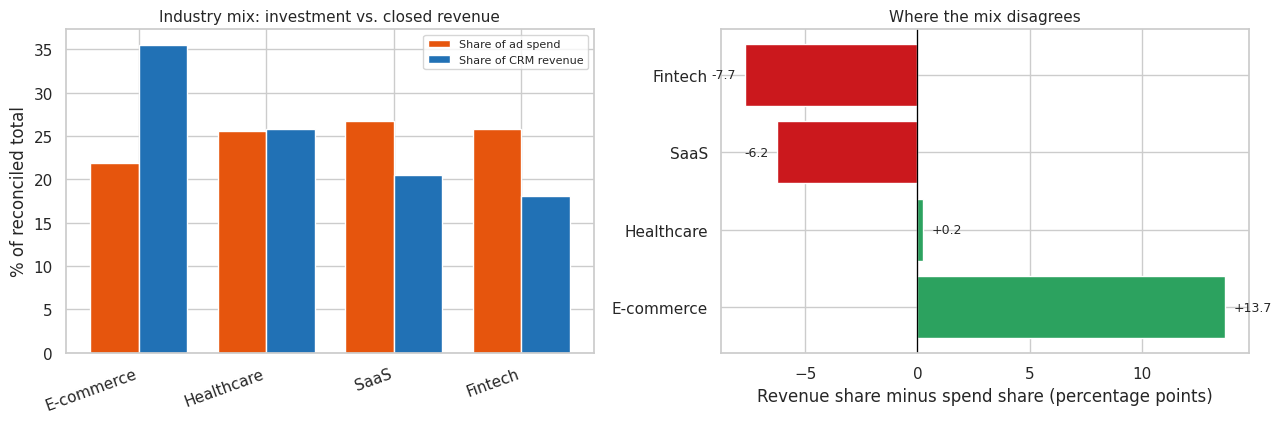

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Left — paired mix bars
ax = axes[0]
x = np.arange(len(mix))
w = 0.38
ax.bar(x - w/2, mix['spend_share'] * 100, w, label='Share of ad spend', color='#e6550d')
ax.bar(x + w/2, mix['revenue_share'] * 100, w, label='Share of CRM revenue', color='#2171b5')
ax.set_xticks(x)
ax.set_xticklabels(mix['industry'], rotation=20, ha='right')
ax.set_ylabel('% of reconciled total')
ax.set_title('Industry mix: investment vs. closed revenue', fontsize=11)
ax.legend(fontsize=8)

# Right — the gap
ax = axes[1]
colors = ['#2ca25f' if v > 0 else '#cb181d' for v in mix['gap_pp']]
ax.barh(mix['industry'], mix['gap_pp'], color=colors)
ax.axvline(0, color='black', lw=0.9)
ax.set_xlabel('Revenue share minus spend share (percentage points)')
ax.set_title('Where the mix disagrees', fontsize=11)
for i, v in enumerate(mix['gap_pp']):
    ax.text(v + (0.4 if v > 0 else -0.4), i, f'{v:+.1f}', va='center',
            ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

### How far this can be pushed — and where it stops

The mix comparison is descriptive. It says the industry *composition* of spend differs from the
industry *composition* of closed revenue by the amounts shown.

It does **not** say that shifting budget toward the positive bars would produce more revenue.
Every constraint from notebook 02 still binds:

- The two sides describe **different six-year-apart periods** (A1). Nothing here is a
  time-series relationship, and the mix gap could be entirely explained by the business having
  changed between 2017 and 2024.
- `E-commerce`→`retail` is a **Medium**-confidence mapping that over-attributes, because the
  CRM's retail sector includes accounts no e-commerce campaign would target.
- Sector is an **audience-overlap proxy** (A2), not evidence that any ad reached any account.
- The revenue figures on the two sides **do not mean the same thing** (finding #8) — this chart
  compares shares, not levels, which is the only reason it is defensible at all.

The honest use of this chart is as a **prompt for investigation**, not a budget instruction:
these are the industries where the two systems disagree most about where the business is, and
they are where a properly instrumented attribution setup would pay for itself first.

---

## Step 8 — Persist the crosswalk and the reconciled baseline

The crosswalk ships as an inspectable CSV. It is the deliverable a domain expert can correct
without touching the notebook, and the seed for the shared reference table recommended in
the README.

In [12]:
import os
os.makedirs('../output', exist_ok=True)

crosswalk_out = crosswalk[['ads_industry', 'crm_sector', 'confidence', 'direction', 'rationale']]
crosswalk_out.to_csv('../output/industry_crosswalk.csv', index=False)

# The crosswalk is only useful if it survives being written and read back. Sentinel values
# like "None"/"NA"/"null" are silently coerced by pandas on read, which would turn a documented
# coverage gap into an indistinguishable missing value.
_rt = pd.read_csv('../output/industry_crosswalk.csv')
assert _rt['confidence'].notna().all(), "confidence values lost on CSV round-trip"
assert set(_rt['confidence']) == set(crosswalk_out['confidence']), "confidence values altered on round-trip"
assert len(_rt) == len(crosswalk_out), "rows lost on round-trip"

reconciled_row = pd.DataFrame([{
    'stage': 'reconciled_crosswalk',
    'ads_categories': n_ads_cats,
    'crm_categories': crm_by_sector['sector'].nunique(),
    'matched_categories': cat_matched,
    'category_match_rate': cat_matched / n_ads_cats,
    'ad_spend_total': AD_SPEND_TOTAL,
    'ad_spend_matched': spend_matched,
    'ad_spend_coverage': spend_matched / AD_SPEND_TOTAL,
    'crm_revenue_total': CRM_REVENUE_TOTAL,
    'crm_revenue_matched': rev_matched,
    'crm_revenue_coverage': rev_matched / CRM_REVENUE_TOTAL,
    'ads_reported_revenue': ads_by_industry['ad_revenue'].sum(),
    'revenue_definition_gap': ads_by_industry['ad_revenue'].sum() / CRM_REVENUE_TOTAL,
}])
reconciled_row.to_csv('../output/baseline_reconciled.csv', index=False)

mix.to_csv('../output/mix_comparison.csv', index=False)

# Same denominator guard as nb 02 — the before/after rows must be comparable
assert np.isclose(reconciled_row['ad_spend_total'].iloc[0], baseline['ad_spend_total'].iloc[0])
assert np.isclose(reconciled_row['crm_revenue_total'].iloc[0], baseline['crm_revenue_total'].iloc[0])
assert list(reconciled_row.columns) == list(baseline.columns), \
    "schema drift: nb 04 concatenates these two rows and needs identical columns"

print("Saved:")
print("  output/industry_crosswalk.csv    <- the deliverable; review this, not the notebook")
print("  output/baseline_reconciled.csv   <- 'after' row for nb 04")
print("  output/mix_comparison.csv")
print()
print("Schema matches baseline_naive.csv — nb 04 can concat the two rows directly.")
reconciled_row.T

Saved:
  output/industry_crosswalk.csv    <- the deliverable; review this, not the notebook
  output/baseline_reconciled.csv   <- 'after' row for nb 04
  output/mix_comparison.csv

Schema matches baseline_naive.csv — nb 04 can concat the two rows directly.


,0
stage,reconciled_crosswalk
ads_categories,5
crm_categories,10
matched_categories,4
category_match_rate,0.8
ad_spend_total,11108749.09
ad_spend_matched,8811770.57
ad_spend_coverage,0.793228
crm_revenue_total,10005534.0
crm_revenue_matched,5255965.0


---

## Findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | Crosswalk lifts ads-category coverage from **0% to 80%** | 4 of 5 ads industries mapped |
| 2 | Ad spend reconciled: **0% → 79.3%** | \$8.81M of \$11.11M, same denominator as the naive baseline |
| 3 | CRM revenue reconciled: **0% → 52.5%** | \$5.26M of \$10.01M |
| 4 | Coverage is **asymmetric by construction** | CRM describes 10 sectors; ads buys against 5. The residual is business the platform never targeted, not mapping debt |
| 5 | `EdTech` has **no CRM counterpart** | \$2.30M of spend permanently unreconcilable via this key |
| 6 | One undocumented sector is worth **15.1pp of coverage** | `technolgy` = \$1.52M; including it would more than double SaaS-mapped revenue |
| 7 | The CRM data dictionary **defines `sector` as "Industry"** | No definition, owner, or examples for the field the entire join depends on |

## What the crosswalk did and did not fix

It fixed the semantic layer — one of five root causes. Restating the boundary, because this is
the point at which an analyst is most tempted to overclaim:

| Problem | Status after this notebook |
|---|---|
| Taxonomy mismatch | **Addressed** — 79.3% of spend, 52.5% of revenue now comparable |
| No shared identifier | Unchanged — still no deal-level attribution |
| No channel field in CRM | Unchanged — still no Google/Meta/TikTok breakdown |
| Non-overlapping dates | Unchanged — still no time-lagged analysis |
| Ads pre-aggregated at source | Unchanged |
| Revenue definitions differ 5.4x (finding #8) | **Unchanged — and untouchable by a category mapping** |

The crosswalk is a **stopgap**, and a fragile one: it is a static file that will silently rot
the first time either team adds a category. It buys time for the durable fixes, which are a
`lead_source` field at the point of data entry and a jointly-owned reference table with a named
owner for each value. See the Recommendation section of the README.

---

**Next:** `04_before_after.ipynb` — concat `baseline_naive.csv` and `baseline_reconciled.csv`,
build the headline before/after comparison.